In [82]:
#Imports:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re 


In [83]:
#Load the data
df= pd.read_csv('/Users/preciousajilore/Documents/GitHub/torchmtlr/notebooks/x_before_with_outcomes.csv')

In [84]:
df.columns

Index(['Unnamed: 0', 'stxlocation', 'distal', 'penile', 'stxetiology',
       'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes',
       'copd', 'smoker', 'bmi35+', 'bmiexact', 'prevprocedure',
       '#prevprocedures', 'cysto', 'open', 'ordate', 'urine', 'failure',
       'patent', 'satisfaction'],
      dtype='object')

In [85]:
df

,Unnamed: 0,stxlocation,distal,penile,stxetiology,stxlength,#strictures,charlsons,cormorbidity,diabetes,...,bmiexact,prevprocedure,#prevprocedures,cysto,open,ordate,urine,failure,patent,satisfaction
0,0,0,0,1.0,2,3.5,1,0,1.0,1,...,NaN,1.0,3,2,0,2003-08-05 00:00:00,0,0,1.0,NaN
1,1,0,0,1.0,4,5,1,0,0.0,0,...,NaN,1.0,5,2,1,2003-08-06 00:00:00,1,0,1.0,yes
2,2,2,0,0.0,1,3,1,0,0.0,0,...,NaN,0.0,0,0,0,2003-08-21 00:00:00,0,0,1.0,yes
3,3,0,0,1.0,4,6.5,1,0,0.0,0,...,38,1.0,10,3,1,2003-08-28 00:00:00,0,1,1.0,yes
4,4,1,0,0.0,1,1,1,1,1.0,0,...,NaN,1.0,2,1,0,2003-08-28 00:00:00,0,0,1.0,Not patient died approx 1.5 years post op from...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1982,1982,1,0,0.0,0,5,1,0,NaN,0,...,NaN,1.0,1,0,0,NaN,0,0,1.0,1
1983,1983,3,1,1.0,0,12,1,0,NaN,0,...,38,1.0,1,0,0,NaN,0,0,NaN,NaN
1984,1984,2,0,0.0,4,4,1,0,NaN,0,...,NaN,1.0,2,0,1,NaN,0,0,NaN,NaN
1985,1985,3,1,1.0,5,14,1,0,NaN,0,...,NaN,1.0,5,0,1,NaN,0,0,2.0,1


In [86]:
df[df["failure"] == 1]

,Unnamed: 0,stxlocation,distal,penile,stxetiology,stxlength,#strictures,charlsons,cormorbidity,diabetes,...,bmiexact,prevprocedure,#prevprocedures,cysto,open,ordate,urine,failure,patent,satisfaction
3,3,0,0,1.0,4,6.5,1,0,0.0,0,...,38,1.0,10,3,1,2003-08-28 00:00:00,0,1,1.0,yes
8,8,1,0,0.0,5,5,1,0,0.0,0,...,NaN,1.0,2,1,0,2003-11-10 00:00:00,0,1,0.0,NaN
9,9,1,0,0.0,1,5,1,0,0.0,0,...,NaN,1.0,1,1,0,2003-11-10 00:00:00,0,1,0.0,NaN
15,15,1,1,0.0,3,6,1,2,1.0,0,...,NaN,1.0,5,2,1,2004-01-19 00:00:00,0,1,0.0,yes
20,20,3,1,1.0,2,15,1,2,1.0,0,...,NaN,1.0,5,3,1,2004-02-05 00:00:00,0,1,0.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1922,1922,3,1,1.0,6,10,1,1,1.0,1,...,39.6,1.0,1,0,0,2023-06-22 00:00:00,0,1,1.0,1
1929,1929,3,1,1.0,priapism,13,1,1,NaN,1,...,NaN,1.0,1,0,0,NaN,1,1,1.0,1
1931,1931,2,0,0.0,3,3,1,2,NaN,0,...,34,1.0,1,0,0,NaN,0,1,1.0,1
1943,1943,3,1,1.0,2,18,1,0,NaN,0,...,30.85,1.0,1,0,0,NaN,0,1,0.0,1


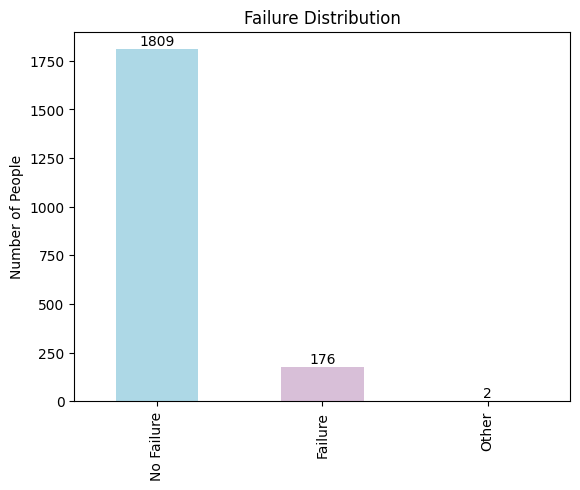

No Failure    1809
Failure        176
Other            2
Name: count, dtype: int64


In [87]:
# Count each value
# Define the order and labels for all expected values
failure_vals = [0, 1, 2]
failure_labels = ['No Failure', 'Failure', 'Other']
colors = ['lightblue', 'thistle', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
counts = df['failure'].value_counts().sort_index().reindex(failure_vals, fill_value=0)
counts.index = failure_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = counts.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Failure Distribution')

# Add text labels
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(counts)

In [88]:

for col_name in df.columns:
    print(col_name)
    print(df[col_name].values)


Unnamed: 0
[   0    1    2 ... 1984 1985 1986]
stxlocation
['0' '0' '2' ... '2' '3' '1']
distal
[0 0 0 ... 0 1 0]
penile
[1. 1. 0. ... 0. 1. 0.]
stxetiology
['2' '4' '1' ... '4' '5' '0']
stxlength
['3.5' '5' '3' ... '4' '14' '4.5']
#strictures
[1 1 1 ... 1 1 1]
charlsons
[0 0 0 ... 0 0 0]
cormorbidity
[ 1.  0.  0. ... nan nan nan]
diabetes
[1 0 0 ... 0 0 0]
copd
[0 0 0 ... 0 0 0]
smoker
[2 0 2 ... 2 2 0]
bmi35+
[0 0 0 ... 0 0 0]
bmiexact
[nan nan nan ... nan nan '33']
prevprocedure
[1. 1. 0. ... 1. 1. 1.]
#prevprocedures
['3' '5' '0' ... '2' '5' '1']
cysto
[2 2 0 ... 0 0 0]
open
['0' '1' '0' ... '1' '1' '0']
ordate
['2003-08-05 00:00:00' '2003-08-06 00:00:00' '2003-08-21 00:00:00' ... nan
 nan nan]
urine
['0' '1' '0' ... '0' '0' '0']
failure
[0 0 0 ... 0 0 0]
patent
[ 1.  1.  1. ... nan  2.  2.]
satisfaction
[nan 'yes' 'yes' ... nan '1' nan]


In [89]:
failure_rate = df['failure'].mean() * 100
print(f"Percentage of people with failure: {failure_rate:.2f}%")

Percentage of people with failure: 9.06%


In [90]:
print(df["#prevprocedures"].unique())

['3' '5' '0' '10' '2' '1' '4' '7' '6' '20' '12' '11' nan '8' '13' '50'
 '40' '15' '22' '100' '9' '14' 'slef dilations' 'multiples' 'mulitple'
 'Nr' 'NR' '18']


In [91]:
def clean_prevprocedure(val):
    # Convert to string and lower for comparison
    v = str(val).lower().strip()
    if v in ['multiples', 'mulitple', 'slef dilations']:
        return 5.0
    if v in ['nr', 'nan', '', 'none', 'nan   8']:
        return np.nan
    try:
        return float(v)
    except:
        return np.nan
    

In [92]:
df['#prevprocedures'] = df['#prevprocedures'].apply(clean_prevprocedure)

In [93]:
print(df["#prevprocedures"].unique())

[  3.   5.   0.  10.   2.   1.   4.   7.   6.  20.  12.  11.  nan   8.
  13.  50.  40.  15.  22. 100.   9.  14.  18.]


In [94]:
print(df["#prevprocedures"].dropna().unique())

[  3.   5.   0.  10.   2.   1.   4.   7.   6.  20.  12.  11.   8.  13.
  50.  40.  15.  22. 100.   9.  14.  18.]


In [95]:
df = df.dropna(subset=["#prevprocedures"])

In [96]:
print(df["#prevprocedures"].unique())

[  3.   5.   0.  10.   2.   1.   4.   7.   6.  20.  12.  11.   8.  13.
  50.  40.  15.  22. 100.   9.  14.  18.]


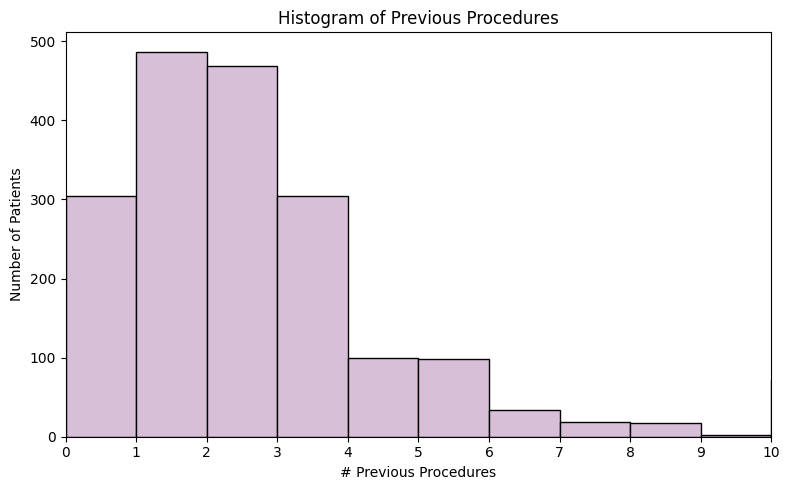

In [97]:

proc = df["#prevprocedures"].dropna().astype(int)
bins = range(proc.min(), proc.max() + 2)

plt.figure(figsize=(8, 5))
plt.hist(proc, bins=bins, edgecolor='black', color='thistle')
plt.xlabel('# Previous Procedures')
plt.ylabel('Number of Patients')
plt.title('Histogram of Previous Procedures')
plt.xticks(range(0, 11))       # Show ticks 0–10 on x-axis
plt.xlim(0, 10)                # Only show 0 to 10 on x-axis
plt.tight_layout()


plt.show()

In [98]:
# Count values 0–10 (you can adjust this range)
proc = df["#prevprocedures"].dropna().astype(int)
value_counts = proc.value_counts().sort_index()

# Limit to 0–10 (most frequent)
value_counts = value_counts.loc[(value_counts.index >= 0) & (value_counts.index <= 100)]

# Calculate percentages
total = value_counts.sum()
percentages = 100 * value_counts / total

# Combine into a table
summary_table = pd.DataFrame({
    'Count': value_counts,
    'Percentage': percentages.round(2)
})

print(summary_table)


                 Count  Percentage
#prevprocedures                   
0                  304       15.72
1                  487       25.18
2                  469       24.25
3                  304       15.72
4                   99        5.12
5                   98        5.07
6                   34        1.76
7                   19        0.98
8                   17        0.88
9                    2        0.10
10                  72        3.72
11                   2        0.10
12                   6        0.31
13                   2        0.10
14                   1        0.05
15                   1        0.05
18                   1        0.05
20                   7        0.36
22                   1        0.05
40                   3        0.16
50                   3        0.16
100                  2        0.10


In [99]:
print(df["copd"].unique())

[0 1]


In [100]:
# Count values 0–10 (you can adjust this range)
copd_detail = df["copd"].dropna().astype(int)
value_counts = copd_detail.value_counts().sort_index()

# Limit to 0–10 (most frequent)
value_counts = value_counts.loc[(value_counts.index >= 0) & (value_counts.index <= 1)]

# Calculate percentages
total = value_counts.sum()
percentages = 100 * value_counts / total

# Combine into a table
summary_table = pd.DataFrame({
    'Count': value_counts,
    'Percentage': percentages.round(2)
})

print(summary_table)

      Count  Percentage
copd                   
0      1862       96.28
1        72        3.72


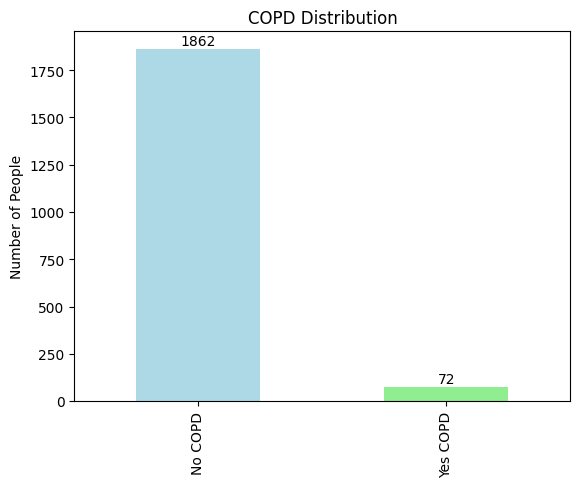

No COPD     1862
Yes COPD      72
Name: count, dtype: int64


In [101]:
# Count each value
# Define the order and labels for all expected values
copd_vals = [0, 1]
copd_labels = ['No COPD', 'Yes COPD']
colors = ['lightblue', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
count = df['copd'].value_counts().sort_index().reindex(copd_vals, fill_value=0)
count.index = copd_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('COPD Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [102]:
df["smoker"].unique()

array([2, 0, 1])

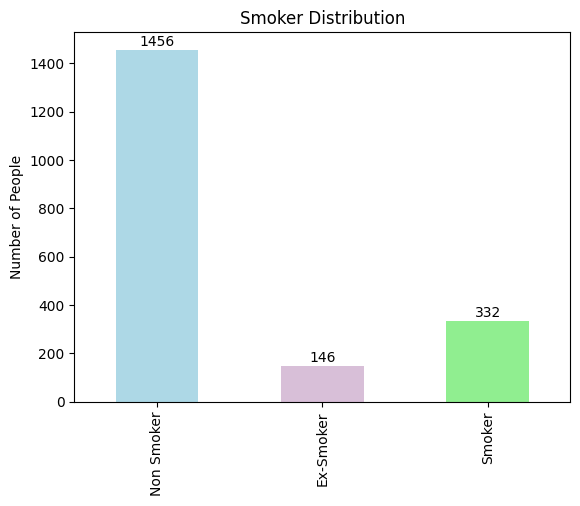

Non Smoker    1456
Ex-Smoker      146
Smoker         332
Name: count, dtype: int64


In [66]:
# Count each value
# Define the order and labels for all expected values
smoker_vals = [0, 1, 2]
smoker_labels = ['Non Smoker', 'Ex-Smoker', 'Smoker']
colors = ['lightblue', 'thistle', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
counts = df['smoker'].value_counts().sort_index().reindex(smoker_vals, fill_value=0)
counts.index = smoker_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax = counts.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Smoker Distribution')

# Add text labels
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(counts)

Unnamed: 0
[   0    1    2 ... 1984 1985 1986]
stxlocation
['0' '0' '2' ... '2' '3' '1']
distal
[0 0 0 ... 0 1 0]
penile
[1. 1. 0. ... 0. 1. 0.]
stxetiology
['2' '4' '1' ... '4' '5' '0']
stxlength
['3.5' '5' '3' ... '4' '14' '4.5']
#strictures
[1 1 1 ... 1 1 1]
charlsons
[0 0 0 ... 0 0 0]
cormorbidity
[ 1.  0.  0. ... nan nan nan]
diabetes
[1 0 0 ... 0 0 0]
copd
[0 0 0 ... 0 0 0]
smoker
[2 0 2 ... 2 2 0]
bmi35+
[0 0 0 ... 0 0 0]
bmiexact
[nan nan nan ... nan nan '33']
prevprocedure
[1. 1. 0. ... 1. 1. 1.]
#prevprocedures
['3' '5' '0' ... '2' '5' '1']
cysto
[2 2 0 ... 0 0 0]
open
['0' '1' '0' ... '1' '1' '0']
ordate
['2003-08-05 00:00:00' '2003-08-06 00:00:00' '2003-08-21 00:00:00' ... nan
 nan nan]
urine
['0' '1' '0' ... '0' '0' '0']
failure
[0 0 0 ... 0 0 0]
patent
[ 1.  1.  1. ... nan  2.  2.]
satisfaction
[nan 'yes' 'yes' ... nan '1' nan]

In [103]:
df["open"].unique()

array(['0', '1', 'no ', 'Yes ', 'no'], dtype=object)

In [111]:
def clean_open(val):
    # Convert to string and lower for comparison
    v = str(val).lower().strip()
    print(f"Value: {v!r}")  # Print each value as it's processed

    if v in ['0', 'no', "No"]:
        return 0
    if v in ['1', 'Yes']:
        return 1
    #return np.nan


In [113]:
df["open"].unique()

array(['0', '1', 'no ', 'Yes ', 'no'], dtype=object)

In [114]:
df["open_clean"] = df["open"].apply(clean_open).dropna()

Value: '0'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '1'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: '1'
Value: '0'
Value: '0'
Value: '0'
Value: '1'
Value: 'no'
Value: '0

/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_11677/792182288.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["open_clean"] = df["open"].apply(clean_open).dropna()


In [118]:
df["open_clean"].unique()

array([ 0.,  1., nan])

In [117]:
print(df["open"].unique())

['0' '1' 'no ' 'Yes ' 'no']


In [119]:
df = df.dropna(subset=['open_clean'])

In [120]:
print(df["open_clean"].unique())

[0. 1.]


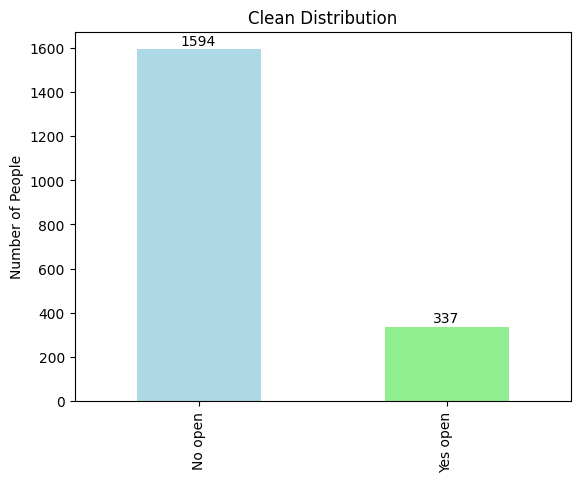

No open     1594
Yes open     337
Name: count, dtype: int64


In [122]:
# Count each value
# Define the order and labels for all expected values
open_vals = [0, 1]
open_labels = ['No open', 'Yes open']
colors = ['lightblue', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
count = df['open_clean'].value_counts().sort_index().reindex(open_vals, fill_value=0)
count.index = open_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Clean Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [123]:
print(df["diabetes"].unique())

[1 0]


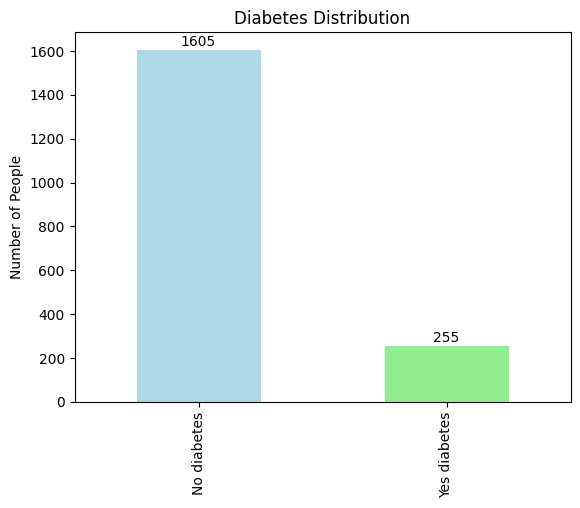

No diabetes     1605
Yes diabetes     255
Name: count, dtype: int64


In [129]:
# Count each value
# Define the order and labels for all expected values
diabetes_vals = [0, 1]
diabetes_labels = ['No diabetes', 'Yes diabetes']
colors = ['lightblue', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
count = df['diabetes'].value_counts().sort_index().reindex(diabetes_vals, fill_value=0)
count.index = diabetes_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Diabetes Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [126]:
print(df["cormorbidity"].unique())

[ 1.  0. nan]


In [128]:
df = df.dropna(subset=['cormorbidity'])

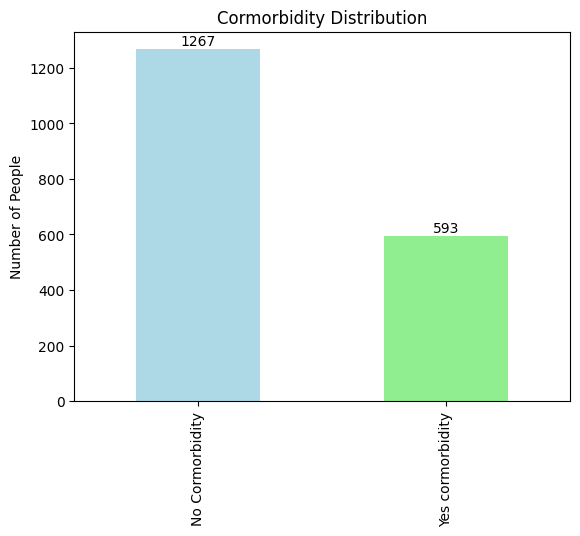

No Cormorbidity     1267
Yes cormorbidity     593
Name: count, dtype: int64


In [130]:
# Count each value
# Define the order and labels for all expected values
corm_vals = [0, 1]
corm_labels = ['No Cormorbidity', 'Yes cormorbidity']
colors = ['lightblue', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
count = df['cormorbidity'].value_counts().sort_index().reindex(corm_vals, fill_value=0)
count.index = corm_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Cormorbidity Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [133]:
print(df["charlsons"].unique())

[ 0  1  2  5  3  4  6  7 11]


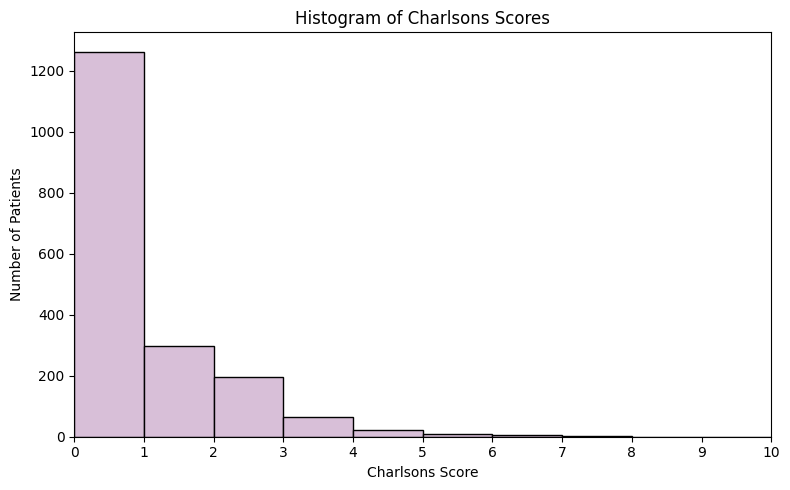

In [135]:

proc = df["charlsons"]
bins = range(proc.min(), proc.max() + 2)

plt.figure(figsize=(8, 5))
plt.hist(proc, bins=bins, edgecolor='black', color='thistle')
plt.xlabel('Charlsons Score')
plt.ylabel('Number of Patients')
plt.title('Histogram of Charlsons Scores')
plt.xticks(range(0, 12))       # Show ticks 0–10 on x-axis
plt.xlim(0, 10)                # Only show 0 to 10 on x-axis
plt.tight_layout()


plt.show()

In [136]:
# Count values 0–10 (you can adjust this range)

value_counts = proc.value_counts().sort_index()

# Limit to 0–10 (most frequent)
value_counts = value_counts.loc[(value_counts.index >= 0) & (value_counts.index <= 100)]

# Calculate percentages
total = value_counts.sum()
percentages = 100 * value_counts / total

# Combine into a table
summary_table = pd.DataFrame({
    'Count': value_counts,
    'Percentage': percentages.round(2)
})

print(summary_table)

           Count  Percentage
charlsons                   
0           1262       67.85
1            297       15.97
2            197       10.59
3             66        3.55
4             21        1.13
5              9        0.48
6              5        0.27
7              2        0.11
11             1        0.05


In [137]:
print(df["#strictures"].unique())

[1 2]


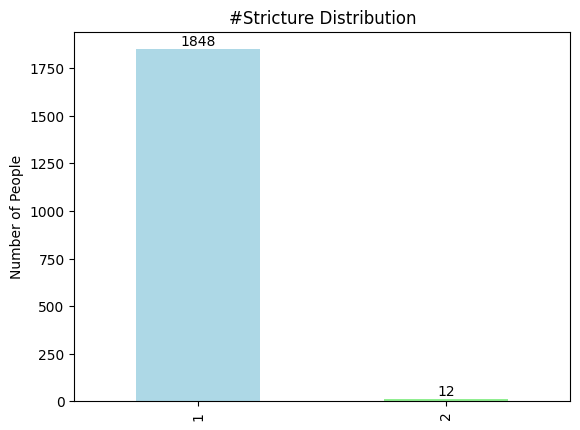

1    1848
2      12
Name: count, dtype: int64


In [139]:
# Count each value
# Define the order and labels for all expected values
str_vals = [1, 2]
str_labels = ['1', '2']
colors = ['lightblue', 'lightgreen']

# Count occurrences, reindex to include zeros for missing classes
count = df['#strictures'].value_counts().sort_index().reindex(str_vals, fill_value=0)
count.index = str_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('#Stricture Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [140]:
df.columns

Index(['Unnamed: 0', 'stxlocation', 'distal', 'penile', 'stxetiology',
       'stxlength', '#strictures', 'charlsons', 'cormorbidity', 'diabetes',
       'copd', 'smoker', 'bmi35+', 'bmiexact', 'prevprocedure',
       '#prevprocedures', 'cysto', 'open', 'ordate', 'urine', 'failure',
       'patent', 'satisfaction', 'open_clean'],
      dtype='object')

In [141]:
print(df["stxlength"].unique())

['3.5' '5' '3' '6.5' '1' '1.5' '2' '5.5' '6' '4' '2.5' '15' '12' '16' '11'
 '9' '7' '18' '4.5' '10' '20' '8' '22' '14' '13' '19' '7.5' '17' '21'
 '0.5' '4 bulbar and 2 penile' '8.5' '10 (penobulbar) + 1,5 (bulbar)']


In [142]:
def split_lengths(val):
    if pd.isna(val):
        return (0.0, 0.0)
    s = str(val)
    nums = re.findall(r'[\d]+[.,]?[\d]*', s)
    nums = [n.replace(',', '.') for n in nums]
    nums = [float(n) for n in nums]
    if len(nums) == 1:
        return (nums[0], 0.0)
    elif len(nums) >= 2:
        return (nums[0], nums[1])
    else:
        return (0.0, 0.0)

In [143]:
df[['stxlength_1', 'stxlength_2']] = df['stxlength'].apply(split_lengths).apply(pd.Series)


/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_11677/3031754979.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['stxlength_1', 'stxlength_2']] = df['stxlength'].apply(split_lengths).apply(pd.Series)
/var/folders/cl/h60hyp6s1jg6rr9n0nfgvphw0000gn/T/ipykernel_11677/3031754979.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['stxlength_1', 'stxlength_2']] = df['stxlength'].apply(split_lengths).apply(pd.Series)


In [146]:
df['stxlength_2'].unique()

array([0. , 2. , 1.5])

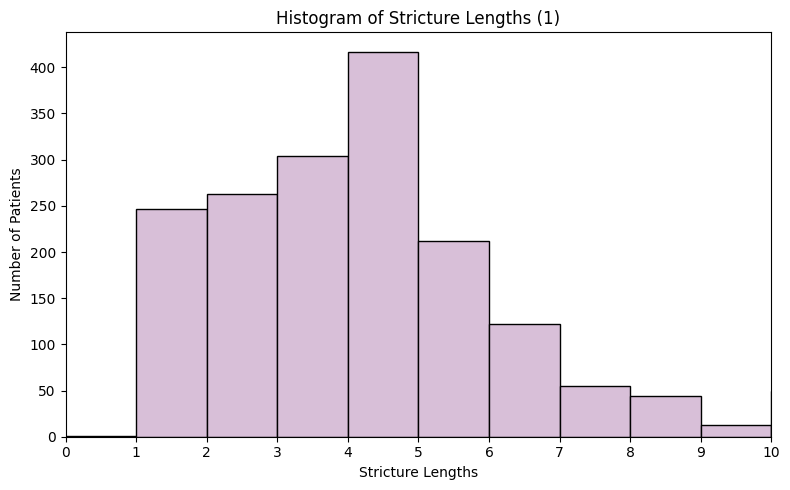

In [152]:

proc = df["stxlength_1"].astype(int)
bins = range(proc.min(), proc.max() + 2)

plt.figure(figsize=(8, 5))
plt.hist(proc, bins=bins, edgecolor='black', color='thistle')
plt.xlabel('Stricture Lengths')
plt.ylabel('Number of Patients')
plt.title('Histogram of Stricture Lengths (1)')
plt.xticks(range(0, 12))       # Show ticks 0–10 on x-axis
plt.xlim(0, 10)                # Only show 0 to 10 on x-axis
plt.tight_layout()


plt.show()

In [153]:
# Count values 0–10 (you can adjust this range)

value_counts = proc.value_counts().sort_index()

# Limit to 0–10 (most frequent)
value_counts = value_counts.loc[(value_counts.index >= 0) & (value_counts.index <= 100)]

# Calculate percentages
total = value_counts.sum()
percentages = 100 * value_counts / total

# Combine into a table
summary_table = pd.DataFrame({
    'Count': value_counts,
    'Percentage': percentages.round(2)
})

print(summary_table)

             Count  Percentage
stxlength_1                   
0                1        0.05
1              247       13.28
2              263       14.14
3              304       16.34
4              417       22.42
5              212       11.40
6              122        6.56
7               55        2.96
8               44        2.37
9               13        0.70
10              49        2.63
11              20        1.08
12              39        2.10
13              10        0.54
14              23        1.24
15               6        0.32
16              12        0.65
17               2        0.11
18              14        0.75
19               3        0.16
20               2        0.11
21               1        0.05
22               1        0.05


In [154]:
print(df["stxetiology"].unique())

['2' '4' '1' '0' '5' '3' '6' '2,4' '6 (chlamydia treated at age 18)']


In [155]:
def split_etiology(val):
    if pd.isna(val):
        return (0, 0)
    s = str(val)
    # Find all integers in the string
    nums = re.findall(r'\d+', s)
    nums = [int(n) for n in nums]
    if len(nums) == 1:
        return (nums[0], 0)
    elif len(nums) >= 2:
        return (nums[0], nums[1])
    else:
        return (0, 0)

In [156]:
df[['stxetiology_1', 'stxetiology_2']] = df['stxetiology'].apply(split_etiology).apply(pd.Series)


In [168]:
print(df["stxetiology_1"].unique())

[2 4 1 0 5 3 6]


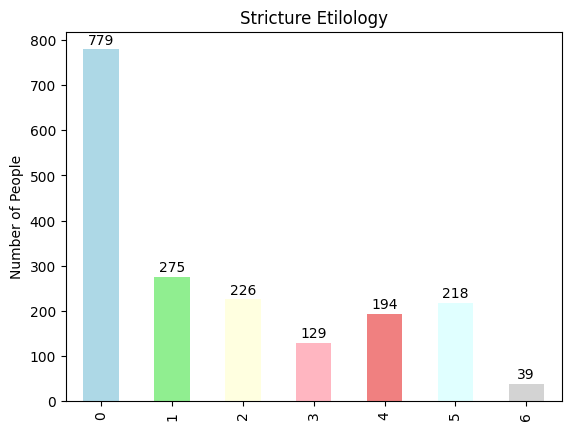

0    779
1    275
2    226
3    129
4    194
5    218
6     39
Name: count, dtype: int64


In [174]:
# Count each value
# Define the order and labels for all expected values
etx_vals = [0, 1, 2, 3, 4, 5, 6]
etx_labels = ['0','1', '2', '3', '4', '5', '6']
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightpink', 'lightcoral', 'lightcyan', 'lightgray']

# Count occurrences, reindex to include zeros for missing classes
count = df['stxetiology_1'].value_counts().sort_index().reindex(etx_vals, fill_value=0)
count.index = etx_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Stricture Etilology')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)

In [176]:
print(df["stxlocation"].unique())

['0' '2' '1' '3' '4' '5' '0 and 1' '1 and 4']


In [164]:
df[['stxlocation_1', 'stxlocation_2']] = df['stxlocation'].apply(split_etiology).apply(pd.Series)


In [178]:
print(df["stxlocation_1"].unique())

[0 2 1 3 4 5]


In [179]:
print(df["stxlocation_2"].unique())

[0 1 4]


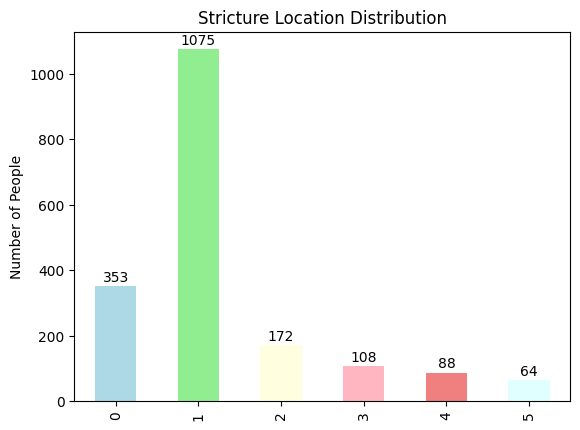

0     353
1    1075
2     172
3     108
4      88
5      64
Name: count, dtype: int64


In [180]:
# Count each value
# Define the order and labels for all expected values
loc_vals = [0, 1, 2, 3, 4, 5]
loc_labels = ['0','1', '2', '3', '4', '5']
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightpink', 'lightcoral', 'lightcyan']

# Count occurrences, reindex to include zeros for missing classes
count = df['stxlocation_1'].value_counts().sort_index().reindex(loc_vals, fill_value=0)
count.index = loc_labels

# Plot

#counts.plot(kind='bar', color=colors)
#plt.ylabel('Number of People')
#plt.title('Failure Distribution')

ax   = count.plot(kind='bar', color=colors)
plt.ylabel('Number of People')
plt.title('Stricture Location Distribution')

# Add text labels
for i, v in enumerate(count):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

print(count)